In [ ]:
# === 複数ファイルの「このステップまでに一度でも発火したtrial比率(CDF)」を
#     イベントごとに重ね描画（凡例にファイル名 + seen/total）====================
import os, json, math, collections
from typing import List, Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt

def _read_first_seen_hist(
    path: str,
    target_events: Optional[List[str]] = None,
    bin_size: int = 1,
) -> Tuple[Dict[str, collections.Counter], int, int, List[str]]:
    hist: Dict[str, collections.Counter] = {}
    total_trials = 0
    max_seen_step = 0
    all_event_names = set()

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)

            # メタデータ行をスキップ
            if "__meta__" in obj:
                continue

            total_trials += 1

            events_list = obj.get("events") or []
            evdict = {}
            for pair in events_list:
                if not pair:
                    continue
                name = str(pair[0])
                steps = pair[1] if len(pair) > 1 else []
                all_event_names.add(name)
                evdict[name] = steps

            names = target_events or evdict.keys()
            for name in names:
                steps = evdict.get(name, [])
                if not steps:
                    continue
                first = int(min(steps))
                if first < 0:
                    continue
                max_seen_step = max(max_seen_step, first)
                bin_idx = first // bin_size
                if name not in hist:
                    hist[name] = collections.Counter()
                hist[name][bin_idx] += 1

    return hist, total_trials, max_seen_step, sorted(all_event_names)

def _counter_to_cdf(
    counter: collections.Counter,
    total_trials: int,
    x_max: int,
    bin_size: int,
) -> Tuple[np.ndarray, np.ndarray, int]:
    nbins = x_max // bin_size + 1
    counts = np.zeros(nbins, dtype=np.int64)
    for b, c in counter.items():
        if 0 <= b < nbins:
            counts[b] += int(c)
    csum = counts.cumsum()
    x = np.arange(nbins) * bin_size
    y = csum / max(total_trials, 1)
    seen = int(csum[-1])
    return x, y, seen

def plot_cdf_overlay_same_event_across_files(
    files: List[str],
    events: Optional[List[str]] = None,   # None: 全ファイル共通イベントを自動抽出
    x_max: Optional[int] = None,          # None: 観測最大 first-step
    bin_size: int = 1,
    title: str = "1 way C-Join",
    ncols: Optional[int] = None,          # None: 2列を目安に自動
    # --- 図サイズ指定 ---
    figsize: Optional[Tuple[float, float]] = None,  # 直接 (幅, 高さ) 指定
    fig_width_per_col: float = 5.0,                 # 列あたり幅（figsize未指定時に使用）
    fig_height_per_row: float = 3.2,                # 行あたり高さ（同上）
    dpi: int = 120,
    # --- 軸ラベルを引数で指定（ここが追加点）---
    x_label: str = "step",
    y_label: str = "fraction of trials",
    # --- 装飾 ---
    legend_loc: str = "lower right",
    legend_fontsize: int = 9,
    suptitle_size: int = 14,
    axes_title_size: int = 12,
):
    # 入力ファイルを全部読む
    per_file = []
    global_max_seen = 0
    all_names_list = []

    for p in files:
        hist, total, mx, names = _read_first_seen_hist(p, target_events=events, bin_size=bin_size)
        per_file.append((hist, total, mx, names, p))
        global_max_seen = max(global_max_seen, mx)
        all_names_list.append(set(names if events is None else events))

    # 対象イベント決定
    if events is None:
        common = set.intersection(*all_names_list) if all_names_list else set()
        events_to_plot = sorted(common)
    else:
        events_to_plot = list(events)

    if not events_to_plot:
        raise ValueError("描画するイベント名が見つかりません。events= で指定するか、ファイル内容をご確認ください。")

    if x_max is None:
        x_max = int(global_max_seen)

    # 図レイアウト
    E = len(events_to_plot)
    if ncols is None:
        ncols = min(E, 2 if E > 1 else 1)
    nrows = math.ceil(E / ncols)

    if figsize is None:
        figsize = (fig_width_per_col * ncols, fig_height_per_row * nrows)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        dpi=dpi,
        squeeze=False,
        sharex=False, sharey=False
    )
    fig.suptitle(title, fontsize=suptitle_size)

    # プロット
    for idx, event_name in enumerate(events_to_plot):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]

        for hist, total, _mx, _names, p in per_file:
            import os
            base = os.path.basename(p)
            counter = hist.get(event_name, collections.Counter())
            x, y, seen = _counter_to_cdf(counter, total, x_max, bin_size)
            ax.plot(x, y, label=f"{base}  (seen {seen}/{total})")

        ax.set_title(event_name, fontsize=axes_title_size)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_xlim(0, x_max)
        ax.set_ylim(0.0, 1.0)
        ax.grid(True, alpha=0.3)
        ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=True)

    # 余りの空Axesを削除
    for j in range(E, nrows * ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r][c])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

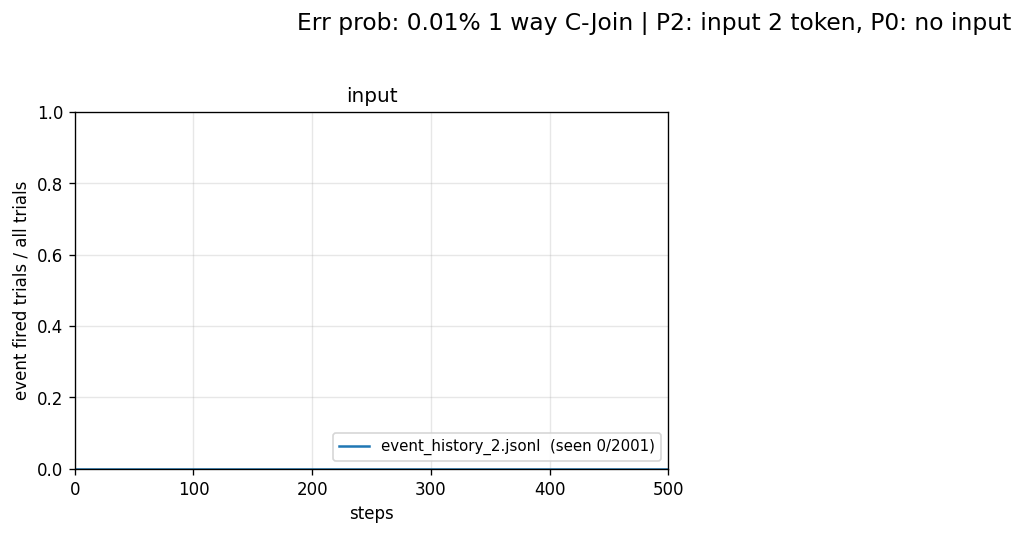

In [6]:
files = [
    "event_history_2.jsonl",
]
events   = ["input"]
x_max    = 500
bin_size = 1

plot_cdf_overlay_same_event_across_files(
    files=files,
    events=events,
    x_max=x_max,
    bin_size=bin_size,
    title="Err prob: 0.01% 1 way C-Join | P2: input 2 token, P0: no input",
    ncols=2,
    fig_width_per_col=5.5,
    fig_height_per_row=4.5,
    dpi=120,
    # 軸タイトルを引数で指定
    x_label="steps",
    y_label="event fired trials / all trials",
)